# 4.1 — Modèles sensibles à l'échelle

Cette famille regroupe les modèles dont la fonction objectif ou la métrique de similarité dépend de l'**échelle** des features — donc **tous** doivent recevoir des données normalisées (`preprocessor_scaled`).

| Modèle           | Hypothèse principale                                                                                  |
|------------------|--------------------------------------------------------------------------------------------------------|
| OLS              | Linéarité, résidus normaux et homoscédastiques, pas de multicolinéarité parfaite                       |
| Ridge            | Idem OLS, tolère la multicolinéarité par shrinkage — features comparables en échelle indispensables   |
| Lasso            | Idem Ridge + parcimonie : suppose qu'une minorité de coefficients sont non-nuls                        |
| ElasticNet       | Compromis Ridge/Lasso                                                                                  |
| KNN              | Distance euclidienne pertinente — features comparables en échelle indispensables                       |
| MLPRegressor     | Approximation lisse par réseau de neurones — descente de gradient sensible à l'échelle                |
| SVR              | Marge ε-insensible + noyau RBF basé sur les distances — mise à l'échelle obligatoire                   |

In [1]:
%load_ext autoreload
%autoreload 2
%run 2_data_prep.ipynb

Dimensions brutes : (1460, 81)
Nombre de points supprimés : 2
Dimensions après suppression : (1458, 81)
Variables après ingénierie : 90 colonnes (+8 dérivées)
Corrélation des variables dérivées avec SalePrice_log :
  TotalSF            : +0.825
  TotalBathrooms     : +0.677
  HouseAge           : -0.588
  YearsSinceRemodel  : -0.569
  GarageAge          : -0.543
  HasGarage          : +0.323
  HasSecondFloor     : +0.151
  HasPool            : +0.077   <-- faible (|r| < 0.1)
X_train : (1166, 83)   |   X_test : (292, 83)
Colonnes retirées (colinéarité) : ['GarageArea', 'TotalBsmtSF', 'TotRmsAbvGrd', 'GarageYrBlt']
NaN dans X_train : 6276 cellules sur 96778
Audit de cardinalité des colonnes nominales (sur X_train) :
Colonne           modalités   bucket
  Neighborhood           25     TargetEncoder (haute)  [imput. mode]
  Exterior2nd            16     TargetEncoder (haute)  [imput. mode]
  Exterior1st            15     TargetEncoder (haute)  [imput. mode]
  MSSubClass             15     

In [2]:
import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.linear_model import LinearRegression, Ridge, RidgeCV, Lasso, LassoCV, ElasticNet, ElasticNetCV
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor

FAMILY = 'scaled'


## 4.1.1 Baseline Métier : Régression Linéaire Restreinte (5 variables)

Avant de lancer notre OLS sur l'ensemble des features encodées, nous établissons une baseline "métier". Ce modèle simule l'estimation d'un agent immobilier qui ne regarderait que les 5 critères principaux d'un bien.


OLS Baseline (5 features) — CV RMSLE: 0.1514   Holdout RMSLE: 0.1643   fit_time: 0.01s


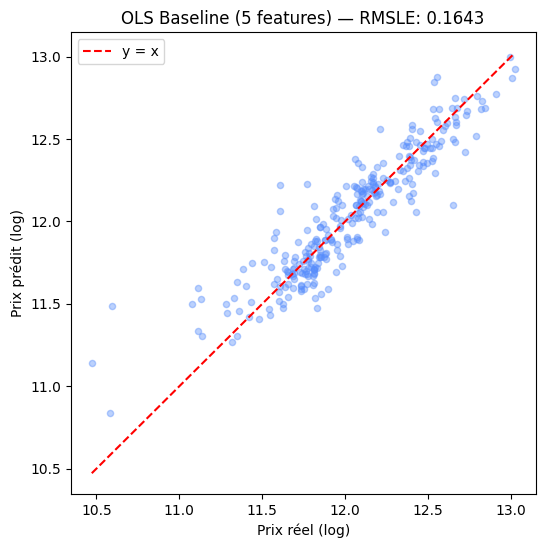

In [3]:
from sklearn.impute import SimpleImputer

baseline_features = ['TotalSF', 'OverallQual', 'HouseAge', 'TotalBathrooms', 'GarageCars']

baseline_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', LinearRegression())
])

X_train_base = X_train[baseline_features]
X_test_base = X_test[baseline_features]

t0 = time.time()
baseline_pipe.fit(X_train_base, y_train_log)
base_fit_s = time.time() - t0

base_cv = cv_rmsle(baseline_pipe, X_train_base, y_train_log)

base_pred_log = baseline_pipe.predict(X_test_base)
base_holdout = rmsle_score(y_test_log, base_pred_log)

print(f"OLS Baseline (5 features) — CV RMSLE: {base_cv:.4f}   Holdout RMSLE: {base_holdout:.4f}   fit_time: {base_fit_s:.2f}s")

publish_result(FAMILY, 'OLS_Baseline_5Feats', cv_rmsle=base_cv, holdout_rmsle=base_holdout, fit_time_s=base_fit_s)

predicted_vs_actual_plot(y_test_log, base_pred_log, title=f"OLS Baseline (5 features) — RMSLE: {base_holdout:.4f}")
plt.show()

## 4.1.2 OLS (Régression Linéaire Classique)

### Conditions de fiabilité du modèle
1. **Logique proportionnelle (Linéarité)** entre nos critères et le prix — vérifiable en s'assurant que les erreurs de prédiction ne forment pas de motif géométrique.
2. **Indépendance des erreurs** — vérifiable en contrôlant qu'une mauvaise estimation sur une maison n'influence pas le calcul de la suivante.
3. **Stabilité de la marge d'erreur (Homoscédasticité)** — vérifiable en s'assurant que le modèle est tout aussi précis pour les biens bon marché que pour l'immobilier de luxe.
4. **Répartition classique des erreurs (Normalité)** — vérifiable en s'assurant graphiquement que le modèle fait beaucoup de petites erreurs et très peu d'écarts extrêmes.
5. **Absence de redondance (Colinéarité)** — partiellement résolue en retirant manuellement les critères qui font doublon (ex: surface du garage vs nombre de voitures).

**Préparation des données** : `preprocessor_scaled` — La régression classique n'a pas strictement besoin d'avoir toutes ses variables sur la même échelle, mais nous l'appliquons pour garantir la robustesse et la stabilité mathématique des calculs.

OLS — CV RMSLE: 0.1215   Holdout RMSLE: 0.1170   fit_time: 0.08s


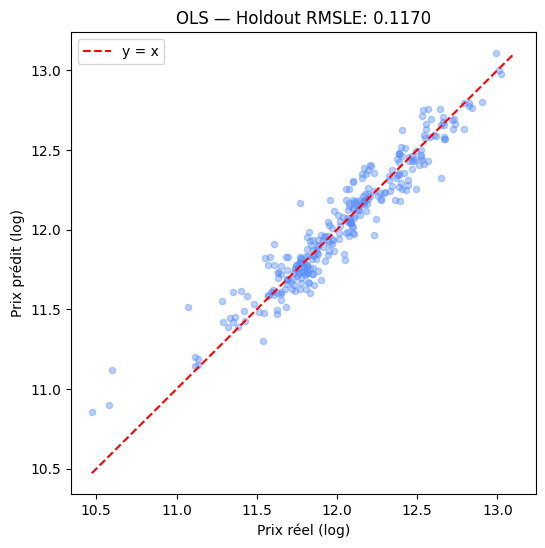

WindowsPath('results/family_scaled.json')

In [4]:
t0 = time.time()
ols_pipe = Pipeline([
    ('preprocessor', preprocessor_scaled),
    ('model', LinearRegression()),
])
ols_pipe.fit(X_train, y_train_log)
ols_fit_s = time.time() - t0

ols_pred_log = ols_pipe.predict(X_test)
ols_holdout = rmsle_score(y_test_log, ols_pred_log)
ols_cv = cv_rmsle(ols_pipe, X_train, y_train_log)

print(f"OLS — CV RMSLE: {ols_cv:.4f}   Holdout RMSLE: {ols_holdout:.4f}   fit_time: {ols_fit_s:.2f}s")
predicted_vs_actual_plot(y_test_log, ols_pred_log, title=f"OLS — Holdout RMSLE: {ols_holdout:.4f}")
plt.show()

publish_result(FAMILY, 'OLS', cv_rmsle=ols_cv, holdout_rmsle=ols_holdout, fit_time_s=ols_fit_s)

### Diagnostic et fiabilité du modèle linéaire (OLS)

Nous utilisons un outil d'analyse statistique avancé sur nos données préparées (en garantissant qu'il n'y a aucune fuite d'information) pour générer un **bilan de santé complet** du modèle. Ce rapport nous fournit l'impact de chaque critère ainsi qu'une série d'indicateurs de robustesse. Nous complétons cette évaluation mathématique par plusieurs graphiques de contrôle visuel :

- **Pertinence de l'approche (Linéarité)** → On vérifie graphiquement que nos erreurs de prédiction sont réparties au hasard, sans former de structure géométrique particulière.
- **Indépendance des erreurs** → On contrôle via un indicateur mathématique qu'une erreur d'estimation sur une maison n'est pas liée à une autre.
- **Stabilité de la marge d'erreur (Homoscédasticité)** → On s'assure par un test spécifique que le modèle reste tout aussi fiable pour estimer les biens bon marché que l'immobilier de luxe.
- **Répartition classique des erreurs (Normalité)** → On vérifie visuellement que le modèle fait beaucoup de petites erreurs et de très rares gros écarts (formant une courbe idéale).

In [5]:
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan

# Le préprocesseur du pipeline OLS est déjà ajusté sur X_train -> on réutilise sa transformation (pas de fuite)
prep_fitted = ols_pipe.named_steps['preprocessor']
X_train_t = prep_fitted.transform(X_train)
X_train_t = X_train_t.toarray() if hasattr(X_train_t, 'toarray') else np.asarray(X_train_t)
feat_names = prep_fitted.get_feature_names_out()

X_sm = sm.add_constant(pd.DataFrame(X_train_t, columns=feat_names, index=X_train.index))
ols_sm = sm.OLS(y_train_log.values, X_sm).fit()

# Résumé complet : coefficients + bloc diagnostics (Durbin-Watson, Omnibus, Jarque-Bera, Cond. No.)
print(ols_sm.summary())

# Homoscédasticité : Breusch-Pagan (absent du résumé statsmodels par défaut)
bp_lm, bp_p, _, _ = het_breuschpagan(ols_sm.resid, X_sm)
print(f"\nBreusch-Pagan (homoscédasticité) : LM={bp_lm:.1f}, p={bp_p:.2e}   (p < 0.05 -> hétéroscédasticité)")

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.934
Model:                            OLS   Adj. R-squared:                  0.927
Method:                 Least Squares   F-statistic:                     140.3
Date:                Sun, 14 Jun 2026   Prob (F-statistic):               0.00
Time:                        15:48:47   Log-Likelihood:                 1009.4
No. Observations:                1166   AIC:                            -1803.
Df Residuals:                    1058   BIC:                            -1256.
Df Model:                         107                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
const   

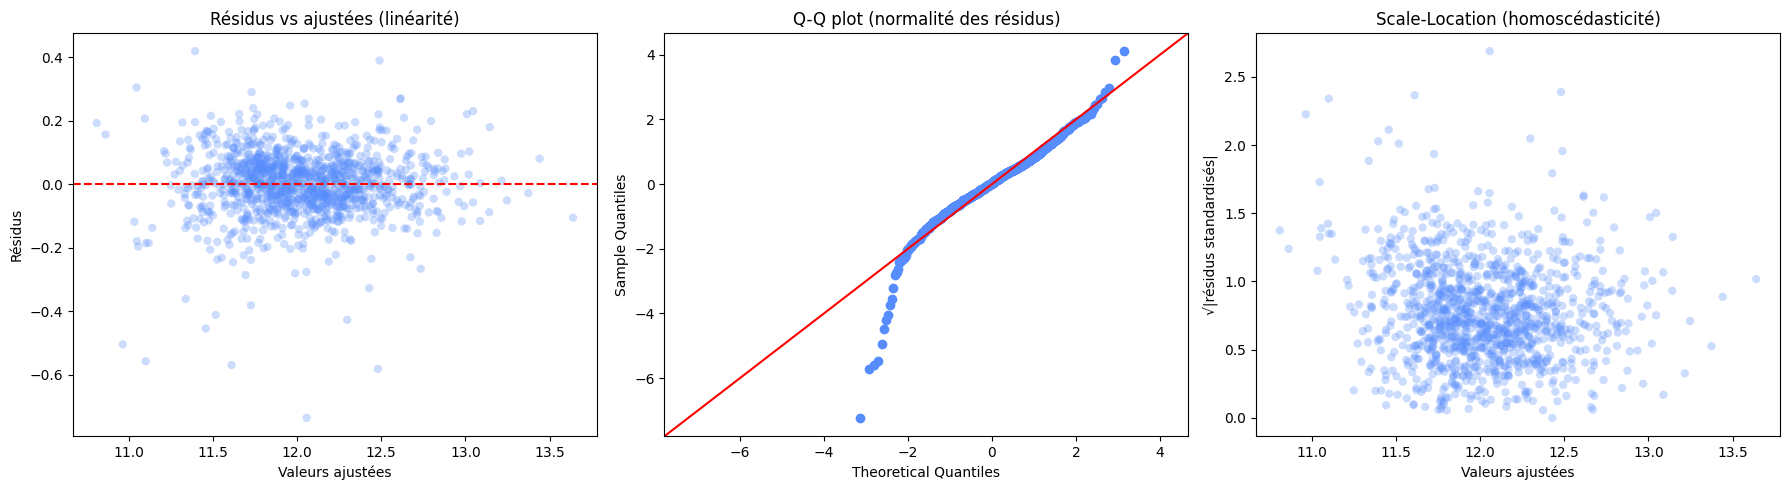

In [6]:
# Graphiques de diagnostic sur les résidus d'entraînement
resid = ols_sm.resid
fitted = ols_sm.fittedvalues
std_resid = resid / resid.std(ddof=1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].scatter(fitted, resid, alpha=0.3, edgecolor='none')
axes[0].axhline(0, color='red', ls='--')
axes[0].set(xlabel='Valeurs ajustées', ylabel='Résidus', title='Résidus vs ajustées (linéarité)')
sm.qqplot(resid, line='45', fit=True, ax=axes[1])
axes[1].set_title('Q-Q plot (normalité des résidus)')
axes[2].scatter(fitted, np.sqrt(np.abs(std_resid)), alpha=0.3, edgecolor='none')
axes[2].set(xlabel='Valeurs ajustées', ylabel='√|résidus standardisés|', title='Scale-Location (homoscédasticité)')
plt.tight_layout()
plt.show()

**Lecture des diagnostics :**

- **Indépendance des erreurs — OK.** Le test (Durbin-Watson ≈ 2.00) confirme que nos erreurs de prédiction ne sont pas liées entre elles. C'est logique et rassurant, car les maisons sont indépendantes les unes des autres (ce n'est pas une évolution chronologique comme le cours d'une action).
- **Stabilité de l'erreur - Homoscédasticité — OK.** Le modèle a une marge d'erreur régulière, que la maison estimée soit bon marché ou très chère. Cela prouve que notre transformation logarithmique du prix a parfaitement fonctionné : sans elle, les erreurs sur les villas de luxe auraient complètement écrasé le reste de nos calculs.
- **Répartition des erreurs (Normalité) — VIOLÉE.** Idéalement, les erreurs devraient former une courbe en cloche parfaite, ce qui n'est pas le cas ici (tests statistiques échoués). Les graphiques montrent que le modèle se trompe lourdement sur quelques cas extrêmes : certaines maisons atypiques sont fortement sous-estimées, car une simple équation linéaire n'est pas assez subtile pour capter le charme d'un bien d'exception.
- **Redondance des variables (Colinéarité) — SÉVÈRE.** L'indicateur de stabilité mathématique s'affole car beaucoup de nos variables se répètent (par exemple, avoir la colonne "sans piscine" est redondant si la colonne "avec piscine" vaut zéro). La régression linéaire classique gère très mal ces doublons, ce qui rend ses calculs instables et justifie l'utilisation de modèles plus avancés (comme le Lasso) juste après.

## 4.1.3 Ridge — Stabilisation des calculs

### Principe et conditions d'utilisation
- Similaire à la régression classique, mais Ridge **réduit l'importance** des critères redondants pour les rapprocher de zéro, sans jamais les ignorer totalement. Il gère ainsi les doublons d'information et rend les estimations beaucoup plus stables.
- La condition absolue : les **critères doivent être sur la même échelle**. Sans cela, la formule mathématique pénaliserait injustement les données avec de grands nombres (comme la surface en pieds carrés) par rapport aux petits nombres (comme le nombre de salles de bain). L'utilisation de notre `preprocessor_scaled` est donc **obligatoire**.

Nous utilisons l'outil `RidgeCV` pour tester plusieurs niveaux de correction et sélectionner automatiquement le meilleur réglage grâce à des tests croisés sur nos données.

Ridge — CV RMSLE: 0.1192   Holdout RMSLE: 0.1237   alpha*: 61.58   fit_time: 0.37s


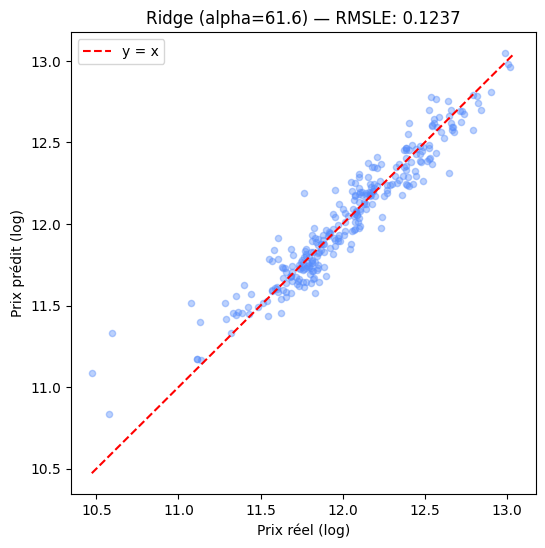

WindowsPath('results/family_scaled.json')

In [7]:
t0 = time.time()
ridge_pipe = Pipeline([
    ('preprocessor', preprocessor_scaled),
    ('model', RidgeCV(alphas=np.logspace(-2, 2, 20), cv=5)),
])
ridge_pipe.fit(X_train, y_train_log)
ridge_fit_s = time.time() - t0
ridge_alpha = ridge_pipe.named_steps['model'].alpha_

ridge_pred_log = ridge_pipe.predict(X_test)
ridge_holdout = rmsle_score(y_test_log, ridge_pred_log)
ridge_cv = cv_rmsle(ridge_pipe, X_train, y_train_log)

print(f"Ridge — CV RMSLE: {ridge_cv:.4f}   Holdout RMSLE: {ridge_holdout:.4f}   alpha*: {ridge_alpha:.4g}   fit_time: {ridge_fit_s:.2f}s")
predicted_vs_actual_plot(y_test_log, ridge_pred_log, title=f"Ridge (alpha={ridge_alpha:.3g}) — RMSLE: {ridge_holdout:.4f}")
plt.show()

publish_result(FAMILY, 'Ridge', cv_rmsle=ridge_cv, holdout_rmsle=ridge_holdout, fit_time_s=ridge_fit_s, params={'alpha': ridge_alpha})

## 4.1.4 Lasso — Simplification et sélection automatique

### Principe et conditions d'utilisation
- Similaire à Ridge, mais avec une approche plus tranchée. Il effectue un **tri automatique des critères** : au lieu de simplement réduire l'impact des variables redondantes, il annule **exactement à zéro** celles qui sont inutiles.
- L'idée de base est qu'un bon modèle doit aller à l'essentiel (être **parcimonieux**) : la grande majorité de nos dizaines de critères n'influence pas réellement le prix de vente final.
- Mettre toutes les données sur la même échelle de lecture est encore plus vital ici qu'avec Ridge pour ne pas fausser ce grand nettoyage automatique.

Lasso — CV RMSLE: 0.1200   Holdout RMSLE: 0.1165   alpha*: 0.0004281   fit_time: 0.12s
  variables annulées : 47 / 129 (36%)


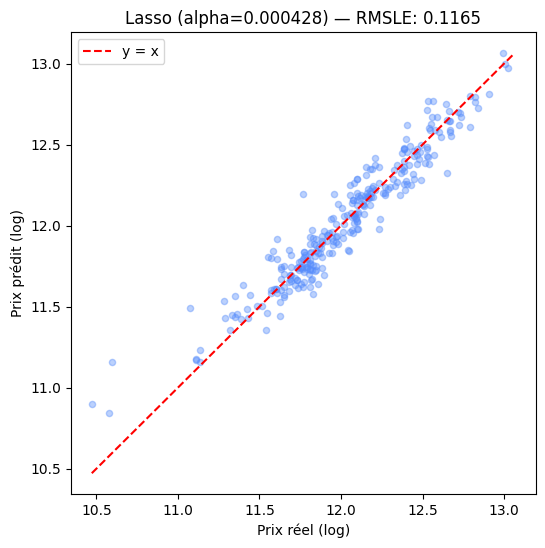

WindowsPath('results/family_scaled.json')

In [8]:
t0 = time.time()
lasso_pipe = Pipeline([
    ('preprocessor', preprocessor_scaled),
    ('model', LassoCV(alphas=np.logspace(-4, 2, 20), cv=5, max_iter=50_000, random_state=RANDOM_STATE)),
])
lasso_pipe.fit(X_train, y_train_log)
lasso_fit_s = time.time() - t0
lasso_alpha = lasso_pipe.named_steps['model'].alpha_

lasso_pred_log = lasso_pipe.predict(X_test)
lasso_holdout = rmsle_score(y_test_log, lasso_pred_log)
lasso_cv = cv_rmsle(lasso_pipe, X_train, y_train_log)

coefs = lasso_pipe.named_steps['model'].coef_
n_zero = int((coefs == 0).sum())
print(f"Lasso — CV RMSLE: {lasso_cv:.4f}   Holdout RMSLE: {lasso_holdout:.4f}   alpha*: {lasso_alpha:.4g}   fit_time: {lasso_fit_s:.2f}s")
print(f"  variables annulées : {n_zero} / {len(coefs)} ({100*n_zero/len(coefs):.0f}%)")
predicted_vs_actual_plot(y_test_log, lasso_pred_log, title=f"Lasso (alpha={lasso_alpha:.3g}) — RMSLE: {lasso_holdout:.4f}")
plt.show()

publish_result(FAMILY, 'Lasso', cv_rmsle=lasso_cv, holdout_rmsle=lasso_holdout, fit_time_s=lasso_fit_s,
               params={'alpha': lasso_alpha, 'n_zero_coefs': n_zero, 'n_total_coefs': len(coefs)})

## 4.1.5 ElasticNet — Le compromis idéal

### Principe et conditions d'utilisation
- Ce modèle combine les forces de nos deux approches précédentes. Il effectue un grand nettoyage en éliminant les critères inutiles (comme le Lasso), tout en répartissant intelligemment l'importance entre les informations qui font doublon (comme Ridge).
- Cette méthode est particulièrement redoutable lorsque nous avons de **nombreux critères qui mesurent presque la même chose** — ce qui est exactement le cas de notre projet immobilier (par exemple, nous avons à la fois la surface du garage en mètres carrés et sa capacité en nombre de voitures).

ElasticNet — CV RMSLE: 0.1196   Holdout RMSLE: 0.1189   alpha*: 0.003793   l1_ratio*: 0.1   fit_time: 0.41s


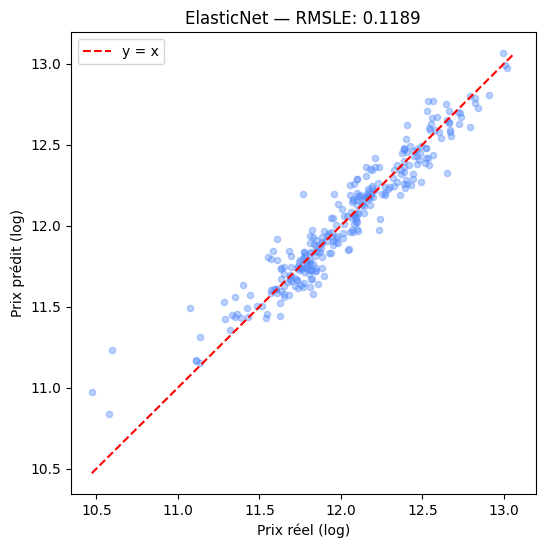

WindowsPath('results/family_scaled.json')

In [9]:
t0 = time.time()
enet_pipe = Pipeline([
    ('preprocessor', preprocessor_scaled),
    ('model', ElasticNetCV(
        l1_ratio=[.1, .5, .7, .9, .95, .99, 1],
        alphas=np.logspace(-4, 2, 20),
        cv=5, max_iter=50_000, random_state=RANDOM_STATE,
    )),
])
enet_pipe.fit(X_train, y_train_log)
enet_fit_s = time.time() - t0
enet_alpha = enet_pipe.named_steps['model'].alpha_
enet_l1 = enet_pipe.named_steps['model'].l1_ratio_

enet_pred_log = enet_pipe.predict(X_test)
enet_holdout = rmsle_score(y_test_log, enet_pred_log)
enet_cv = cv_rmsle(enet_pipe, X_train, y_train_log)

print(f"ElasticNet — CV RMSLE: {enet_cv:.4f}   Holdout RMSLE: {enet_holdout:.4f}   alpha*: {enet_alpha:.4g}   l1_ratio*: {enet_l1}   fit_time: {enet_fit_s:.2f}s")
predicted_vs_actual_plot(y_test_log, enet_pred_log, title=f"ElasticNet — RMSLE: {enet_holdout:.4f}")
plt.show()

publish_result(FAMILY, 'ElasticNet', cv_rmsle=enet_cv, holdout_rmsle=enet_holdout, fit_time_s=enet_fit_s,
               params={'alpha': enet_alpha, 'l1_ratio': enet_l1})

### Visualisation de la simplification — Ridge / Lasso / ElasticNet

Plutôt que de vous donner uniquement le réglage mathématique optimal trouvé par nos tests, nous avons **visualisé l'effet de ce nettoyage** : nous faisons varier la force de la correction et observons comment l'importance de chaque critère immobilier évolue. C'est la meilleure façon de comprendre comment nos algorithmes raisonnent :

- **Ridge** réduit l'impact des critères redondants **en douceur** vers zéro, mais sans jamais les ignorer totalement ;
- **Lasso** met **exactement à zéro** un grand nombre de critères inutiles → il effectue une véritable **sélection automatique des variables** ;
- **ElasticNet** réalise un équilibre intelligent entre ces deux comportements.

Le niveau de correction idéal que nous avons finalement retenu est marqué par une ligne rouge pointillée : elle montre exactement à quel moment notre modèle final a décidé de s'arrêter de nettoyer. Comme toutes nos données ont été remises sur la même échelle de lecture au préalable, l'importance visuelle de ces critères peut être comparée de façon juste et équitable.

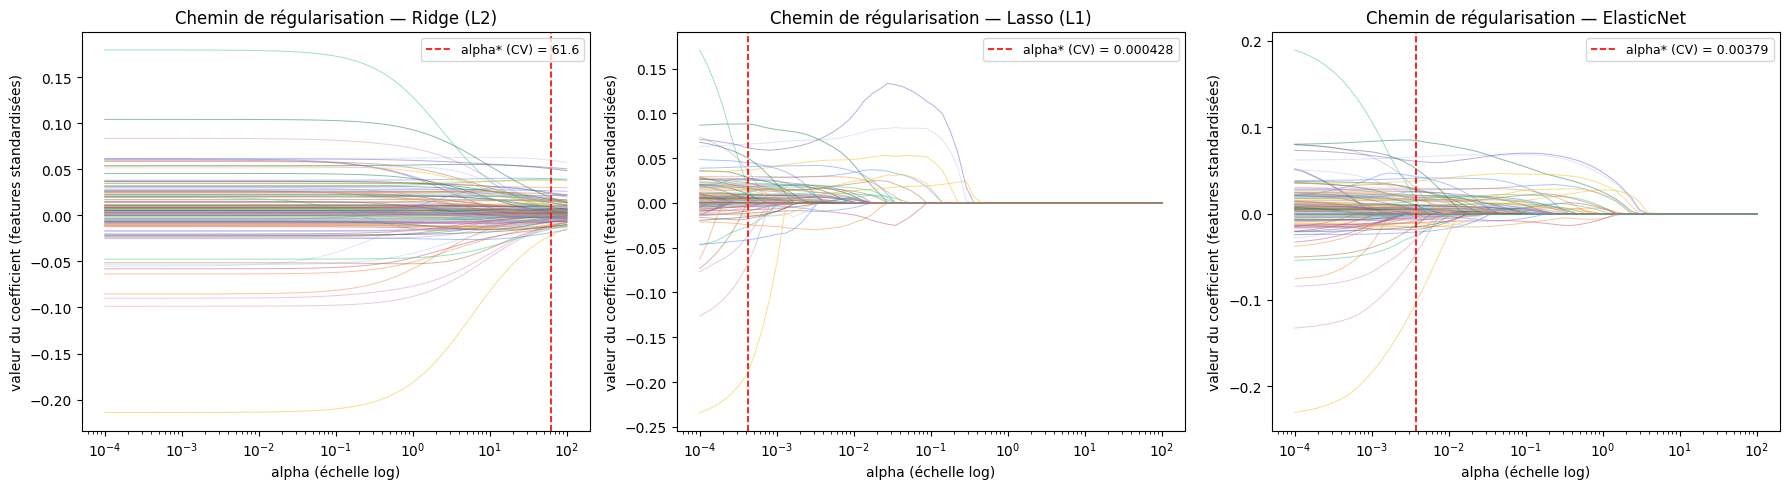

Lasso au alpha* = 0.000428 : 48/129 coefficients exactement nuls (37% des features écartées).


In [10]:
# Chemins de régularisation (diagnostic — ne republie aucun résultat)
from sklearn.base import clone
from sklearn.linear_model import Ridge, Lasso, ElasticNet

# Matrice de design standardisée, ajustée sur le train (clone => aucune dépendance à l'état en place)
_prep = clone(preprocessor_scaled).fit(X_train, y_train_log)
Xtr = _prep.transform(X_train)

alphas = np.logspace(-4, 2, 60)
familles = {
    'Ridge (L2)':   (Ridge(),                                  ridge_alpha),
    'Lasso (L1)':   (Lasso(max_iter=50_000),                   lasso_alpha),
    'ElasticNet':   (ElasticNet(l1_ratio=float(enet_l1), max_iter=50_000), enet_alpha),
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (nom, (est, a_star)) in zip(axes, familles.items()):
    chemin = []
    for a in alphas:
        est.set_params(alpha=a)
        est.fit(Xtr, y_train_log)
        chemin.append(est.coef_)
    chemin = np.asarray(chemin)  # (n_alphas, n_features)
    ax.plot(alphas, chemin, lw=0.7, alpha=0.5)
    ax.set_xscale('log')
    ax.axvline(a_star, color='red', ls='--', lw=1.2, label=f'alpha* (CV) = {a_star:.3g}')
    ax.set_title(f'Chemin de régularisation — {nom}')
    ax.set_xlabel('alpha (échelle log)')
    ax.set_ylabel('valeur du coefficient (features standardisées)')
    ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()

# Parcimonie du Lasso au alpha* retenu
_lasso_star = Lasso(alpha=lasso_alpha, max_iter=50_000).fit(Xtr, y_train_log)
_nz = int((_lasso_star.coef_ == 0).sum())
print(f"Lasso au alpha* = {lasso_alpha:.3g} : {_nz}/{len(_lasso_star.coef_)} coefficients exactement nuls "
      f"({100*_nz/len(_lasso_star.coef_):.0f}% des features écartées).")

**Ce qu'il faut retenir.** Ces trajectoires illustrent visuellement comment chaque algorithme "nettoie" les informations : **Ridge** réduit progressivement l'importance de tous les critères mais **n'en supprime aucun** (il conserve donc des informations peu utiles qui peuvent faire "bruit") ; **Lasso** force une grande partie des critères **exactement à zéro** — c'est un véritable **tri automatique** des données, ce qui explique son excellente performance ici et son rôle de pilier dans notre modèle d'équipe final (le Stacking) ; **ElasticNet** offre un compromis entre les deux. La ligne rouge indique que nos tests ont choisi un niveau de correction modéré — juste assez pour stabiliser nos calculs face aux **quelques doublons d'information restants** (évoqués lors de la préparation des données), sans pour autant brider le modèle. Cette vérification ne modifie pas nos scores de performance, mais elle explique de l'intérieur *pourquoi* nous privilégierons certains modèles dans notre évaluation finale.

## 4.1.6 KNN — K plus proches voisins (Estimation par similitude)

### Principe et conditions d'utilisation
- **Aucune formule mathématique préétablie** : contrairement à la régression linéaire, ce modèle n'impose aucune règle rigide (comme une ligne droite) pour relier les critères de la maison à son prix.
- L'idée centrale est très intuitive : deux maisons qui se ressemblent fortement auront des prix de vente très proches → la mesure mathématique de cette **"ressemblance"** doit donc être parfaite.
- Conséquence absolue : **tous les critères doivent être ramenés à la même échelle**. Sans cela, les grands nombres (comme la surface du terrain) fausseraient totalement l'algorithme au détriment des petits nombres (comme le nombre de salles de bain).

Nous demandons à l'algorithme de tester l'estimation en se basant sur 1 jusqu'à 40 "maisons jumelles" (voisins), et nous sélectionnons automatiquement le nombre idéal grâce à nos tests croisés.

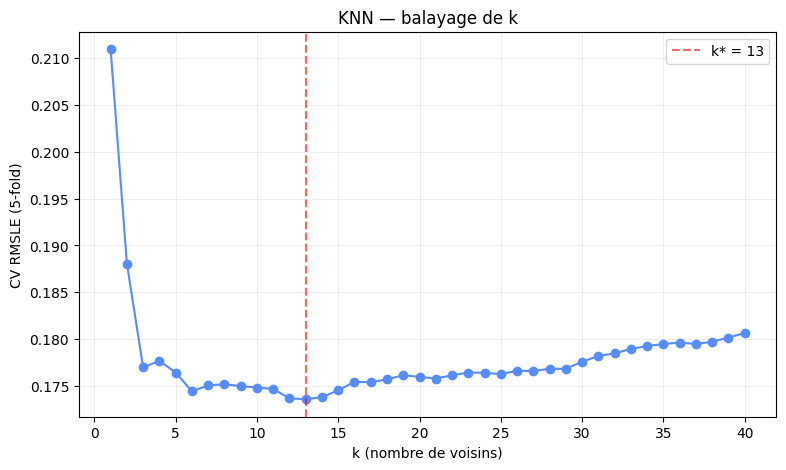

KNN — CV RMSLE: 0.1736   Holdout RMSLE: 0.1850   k*: 13   fit_time (sweep + final): 6.49s


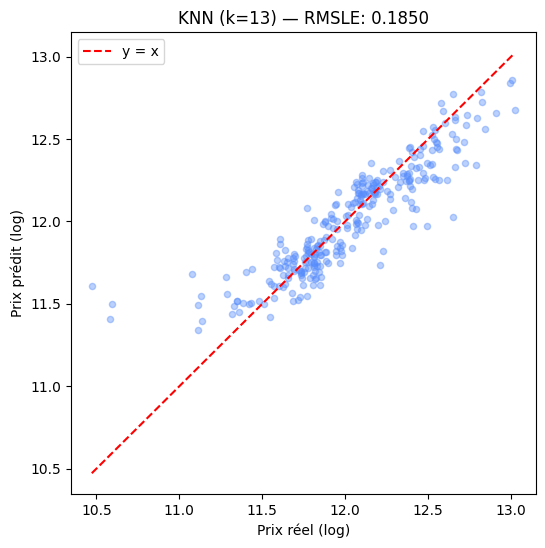

WindowsPath('results/family_scaled.json')

In [11]:
t0 = time.time()
k_range = list(range(1, 41))
knn_cv_scores = []
for k in k_range:
    pipe = Pipeline([('preprocessor', preprocessor_scaled), ('model', KNeighborsRegressor(n_neighbors=k))])
    knn_cv_scores.append(-cross_val_score(pipe, X_train, y_train_log, cv=5,
                                          scoring='neg_root_mean_squared_error', n_jobs=-1).mean())

best_k = int(k_range[int(np.argmin(knn_cv_scores))])

plt.figure(figsize=(9, 5))
plt.plot(k_range, knn_cv_scores, marker='o')
plt.axvline(best_k, color='red', ls='--', alpha=0.6, label=f'k* = {best_k}')
plt.xlabel('k (nombre de voisins)')
plt.ylabel('CV RMSLE (5-fold)')
plt.title("KNN — balayage de k")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

knn_pipe = Pipeline([('preprocessor', preprocessor_scaled), ('model', KNeighborsRegressor(n_neighbors=best_k))])
knn_pipe.fit(X_train, y_train_log)
knn_fit_s = time.time() - t0
knn_pred_log = knn_pipe.predict(X_test)
knn_holdout = rmsle_score(y_test_log, knn_pred_log)
knn_cv = float(min(knn_cv_scores))

print(f"KNN — CV RMSLE: {knn_cv:.4f}   Holdout RMSLE: {knn_holdout:.4f}   k*: {best_k}   fit_time (sweep + final): {knn_fit_s:.2f}s")
predicted_vs_actual_plot(y_test_log, knn_pred_log, title=f"KNN (k={best_k}) — RMSLE: {knn_holdout:.4f}")
plt.show()

publish_result(FAMILY, 'KNN', cv_rmsle=knn_cv, holdout_rmsle=knn_holdout, fit_time_s=knn_fit_s, params={'k': best_k})

## 4.1.7 MLPRegressor — Réseau de Neurones Artificiels

### Principe et conditions d'utilisation
- Ce modèle imite le fonctionnement d'un réseau neuronal pour découvrir des relations très complexes et non linéaires entre les caractéristiques d'une maison et son prix de vente.
- **Processus d'apprentissage** : L'algorithme s'ajuste pas à pas en corrigeant ses erreurs. Il est extrêmement sensible à la taille des nombres : si nos critères ne sont pas tous sur la même échelle, son apprentissage déraille (il s'affole sur les grands nombres et ignore les petits).
- Il nécessite un "cerveau" de la bonne taille et un mécanisme d'**arrêt automatique** pour l'empêcher d'apprendre bêtement notre jeu de données "par cœur" au lieu d'en déduire des règles générales.

La taille du réseau (le nombre de neurones) et ses réglages de correction sont **testés et optimisés par un algorithme de recherche intelligent** (Optuna). Cette étape est vitale : avec notre volume de données très modeste (environ 1200 maisons), un réseau de neurones mal configuré n'arrivera absolument pas à comprendre le marché.

MLP (Optuna) — CV RMSLE: 0.1252   Holdout RMSLE: 0.1251   tuning_time: 97.2s
  architecture : (137, 80, 153), activation=tanh, lr=6.9e-03, alpha=2.5e-06


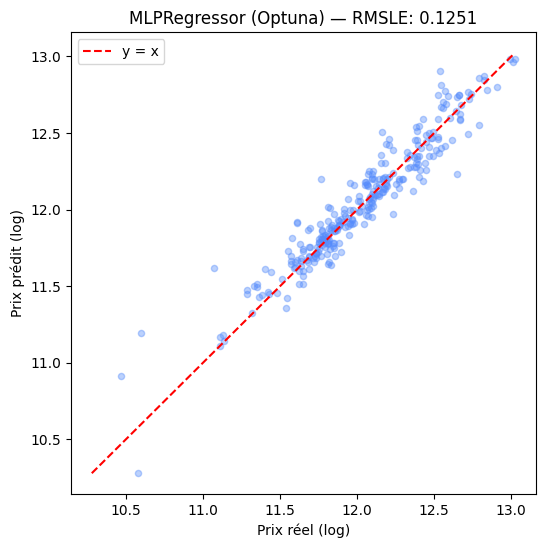

WindowsPath('results/family_scaled.json')

In [12]:
# Tuning Optuna de l'architecture MLP — sampler graine (TPESampler) pour reproductibilite.
def _mlp_objective(trial):
    n_layers = trial.suggest_int('n_layers', 1, 3)
    hidden = tuple(trial.suggest_int(f'n_units_l{i}', 16, 256, log=True) for i in range(n_layers))
    mlp = MLPRegressor(
        hidden_layer_sizes=hidden,
        activation=trial.suggest_categorical('activation', ['relu', 'tanh']),
        solver='adam',
        learning_rate_init=trial.suggest_float('learning_rate_init', 1e-4, 1e-1, log=True),
        alpha=trial.suggest_float('alpha', 1e-6, 1e-2, log=True),
        max_iter=2000, early_stopping=True, validation_fraction=0.1,
        random_state=RANDOM_STATE,
    )
    pipe = Pipeline([('preprocessor', preprocessor_scaled), ('model', mlp)])
    return -cross_val_score(pipe, X_train, y_train_log, cv=5,
                            scoring='neg_root_mean_squared_error', n_jobs=-1).mean()

t0 = time.time()
mlp_study = optuna.create_study(direction='minimize', sampler=TPESampler(seed=RANDOM_STATE))
mlp_study.optimize(_mlp_objective, n_trials=40, show_progress_bar=False)
mlp_fit_s = time.time() - t0

bp = mlp_study.best_params
mlp_hidden = tuple(bp[f'n_units_l{i}'] for i in range(bp['n_layers']))
mlp_pipe = Pipeline([
    ('preprocessor', preprocessor_scaled),
    ('model', MLPRegressor(
        hidden_layer_sizes=mlp_hidden, activation=bp['activation'], solver='adam',
        learning_rate_init=bp['learning_rate_init'], alpha=bp['alpha'],
        max_iter=2000, early_stopping=True, validation_fraction=0.1,
        random_state=RANDOM_STATE,
    )),
]).fit(X_train, y_train_log)
mlp_pred_log = mlp_pipe.predict(X_test)
mlp_holdout = rmsle_score(y_test_log, mlp_pred_log)
mlp_cv = float(mlp_study.best_value)

print(f"MLP (Optuna) — CV RMSLE: {mlp_cv:.4f}   Holdout RMSLE: {mlp_holdout:.4f}   tuning_time: {mlp_fit_s:.1f}s")
print(f"  architecture : {mlp_hidden}, activation={bp['activation']}, lr={bp['learning_rate_init']:.1e}, alpha={bp['alpha']:.1e}")
predicted_vs_actual_plot(y_test_log, mlp_pred_log, title=f"MLPRegressor (Optuna) — RMSLE: {mlp_holdout:.4f}")
plt.show()

publish_result(FAMILY, 'MLPRegressor', cv_rmsle=mlp_cv, holdout_rmsle=mlp_holdout, fit_time_s=mlp_fit_s,
               params={'hidden_layer_sizes': mlp_hidden, 'activation': bp['activation'], 'solver': 'adam'})


## 4.1.8 SVR — Machine à Vecteurs de Support (Estimation par marge de tolérance)

### Principe et conditions d'utilisation
- **Tolérance à l'erreur (Le "tube" de marge)** : Contrairement aux autres modèles, cet algorithme ne cherche pas la perfection absolue à tout prix. Il crée un « tube » d'erreur acceptable autour de sa prédiction et ignore les petites imprécisions. Seules les maisons atypiques situées hors de ce tube forcent le modèle à ajuster ses calculs.
- **Détection de relations complexes** : Il utilise une astuce mathématique puissante pour trouver des liens non-linéaires entre nos critères. Il est capable de repérer des subtilités du marché immobilier que nos modèles précédents en ligne droite (comme Lasso ou Ridge) étaient incapables de voir.
- **Sensibilité à l'échelle** : Comme le modèle compare mathématiquement la "distance" entre les maisons, les critères avec de grands nombres écraseraient complètement les autres. Remettre toutes les données sur la même échelle de lecture (`preprocessor_scaled`) est donc indispensable.
- **Indicateurs de contrôle** : Nous surveillons son erreur globale et surtout la proportion de "maisons atypiques" qu'il est obligé de mémoriser. S'il en mémorise trop, cela indique qu'il commence à apprendre le jeu de données "par cœur" au lieu de généraliser.
- **Limites pour le projet** : C'est un modèle **très gourmand en temps de calcul** (qui risque de ralentir l'application de nos consultants), il est **extrêmement opaque** (difficile d'expliquer le calcul d'un prix à un client), et sa performance dépend énormément de ses réglages de départ (que nous testons et ajustons juste en dessous).

SVR (RBF) — CV RMSLE: 0.1178   Holdout RMSLE: 0.1159   fit_time (grid+final): 3.53s
  meilleurs hyperparamètres : C=10, gamma=0.001, epsilon=0.05
  vecteurs de support : 609/1166 (52%) — élevé = frontière complexe / risque de surapprentissage


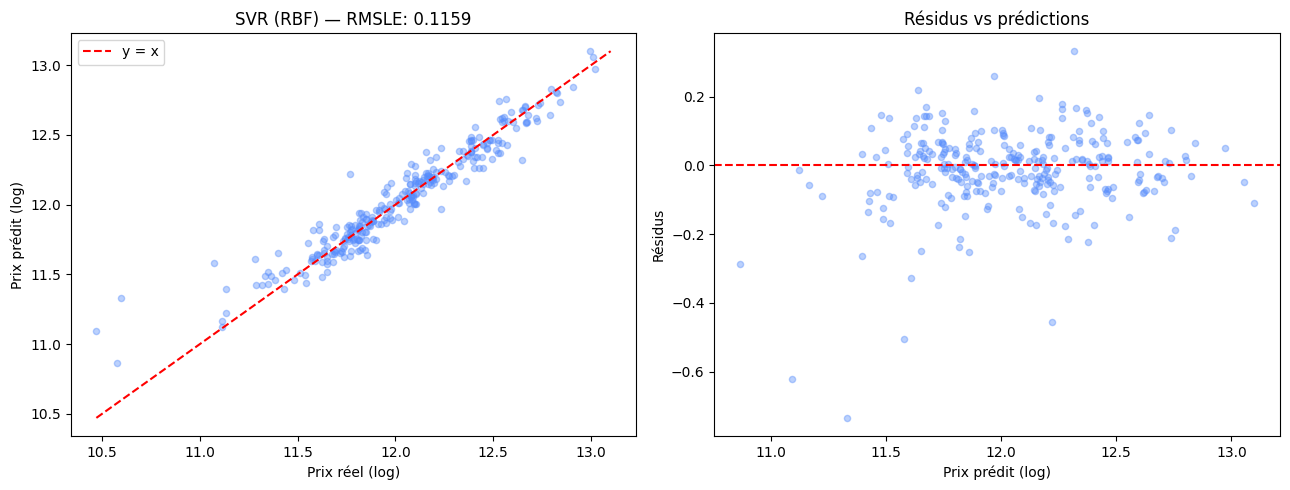

WindowsPath('results/family_scaled.json')

In [13]:
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV

t0 = time.time()
svr_base = Pipeline([('preprocessor', preprocessor_scaled), ('model', SVR(kernel='rbf'))])
svr_grid = {
    'model__C':       [1, 10, 100],
    'model__gamma':   ['scale', 0.01, 0.001],
    'model__epsilon': [0.05, 0.1],
}
svr_search = GridSearchCV(svr_base, svr_grid, cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1)
svr_search.fit(X_train, y_train_log)
svr_fit_s = time.time() - t0

svr_pipe     = svr_search.best_estimator_
svr_cv       = float(-svr_search.best_score_)        # RMSLE CV 5-fold du meilleur config
svr_pred_log = svr_pipe.predict(X_test)
svr_holdout  = rmsle_score(y_test_log, svr_pred_log)
best = svr_search.best_params_
n_sv = int(svr_pipe.named_steps['model'].support_.shape[0])
n_tr = X_train.shape[0]

print(f"SVR (RBF) — CV RMSLE: {svr_cv:.4f}   Holdout RMSLE: {svr_holdout:.4f}   fit_time (grid+final): {svr_fit_s:.2f}s")
print(f"  meilleurs hyperparamètres : C={best['model__C']}, gamma={best['model__gamma']}, epsilon={best['model__epsilon']}")
print(f"  vecteurs de support : {n_sv}/{n_tr} ({100*n_sv/n_tr:.0f}%) — élevé = frontière complexe / risque de surapprentissage")

resid = y_test_log.values - svr_pred_log
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
predicted_vs_actual_plot(y_test_log, svr_pred_log, title=f"SVR (RBF) — RMSLE: {svr_holdout:.4f}", ax=axes[0])
axes[1].scatter(svr_pred_log, resid, alpha=0.4, s=20)
axes[1].axhline(0, color='red', ls='--')
axes[1].set(xlabel='Prix prédit (log)', ylabel='Résidus', title='Résidus vs prédictions')
plt.tight_layout()
plt.show()

publish_result(FAMILY, 'SVR', cv_rmsle=svr_cv, holdout_rmsle=svr_holdout, fit_time_s=svr_fit_s,
               params={'kernel': 'rbf', 'C': best['model__C'], 'gamma': best['model__gamma'],
                       'epsilon': best['model__epsilon'], 'n_support': n_sv})

**Ce qu'il faut retenir.** Ce modèle apporte la capacité de détecter des relations complexes (tout comme le réseau de neurones). Son intérêt réel dépendra de sa précision face à ses lourds défauts : une grande lenteur de calcul et un côté "boîte noire" (difficilement explicable) qui le pénalisent pour une utilisation concrète en agence. Nous ne l'intègrerons dans notre modèle d'équipe final (le Stacking) que s'il prouve qu'il commet des erreurs très différentes des autres algorithmes (apportant un regard unique) ; sinon, il restera une simple démonstration mathématique avancée.

## 4.1.9 Bilan et choix du champion de cette catégorie

Nous comparons maintenant la précision (les marges d'erreur) de tous nos modèles sensibles à l'échelle. Cette évaluation finale nous permet d'élire le **champion de cette famille**. C'est lui qui sera sélectionné pour devenir l'un des piliers de notre grand modèle final (le Stacking, abordé dans le carnet `3d`).

Une fois ce vainqueur identifié, notre recherche continue avec une toute autre approche algorithmique : les **arbres de décision** (`3b`). Ces nouveaux modèles raisonnent de manière radicalement différente, puisqu'ils fonctionnent par paliers (seuils de coupure) et n'ont absolument pas besoin que les données soient remises sur une même échelle de lecture.

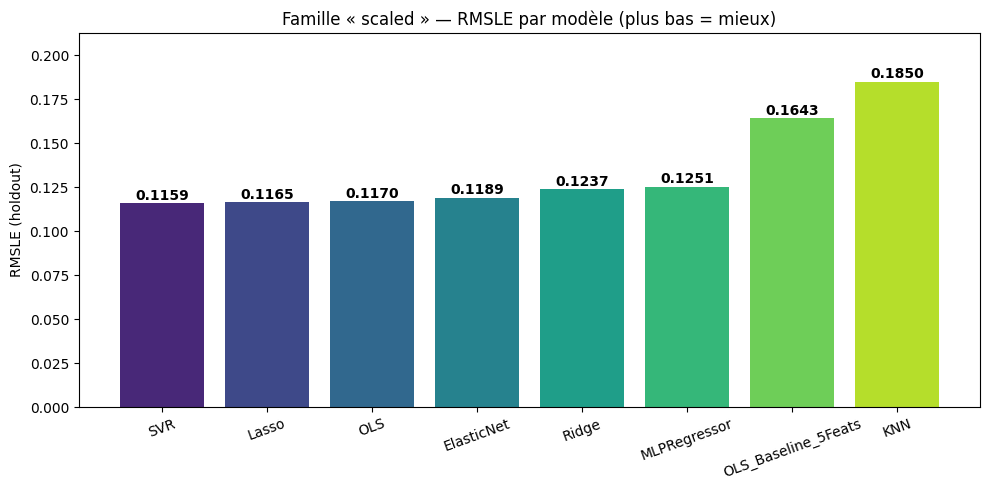

Classement intra-famille (par holdout RMSLE) :


,model,cv_rmsle,holdout_rmsle,fit_time_s
0,SVR,0.117750,0.115885,3.528454
1,Lasso,0.119997,0.116451,0.117971
2,OLS,0.121470,0.116999,0.081279
3,ElasticNet,0.119578,0.118910,0.407035
4,Ridge,0.119154,0.123716,0.374846
5,MLPRegressor,0.125245,0.125092,97.157896
6,OLS_Baseline_5Feats,0.151411,0.164284,0.013514
7,KNN,0.173573,0.184994,6.490833


In [14]:
family_path = RESULTS_DIR / f'family_{FAMILY}.json'
fam = pd.DataFrame(json.loads(family_path.read_text()))
fam = fam.sort_values('holdout_rmsle').reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(fam['model'], fam['holdout_rmsle'], color=sns.color_palette('viridis', len(fam)))
for bar, v in zip(bars, fam['holdout_rmsle']):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.002, f"{v:.4f}", ha='center', fontweight='bold')
ax.set_ylabel('RMSLE (holdout)')
ax.set_title("Famille « scaled » — RMSLE par modèle (plus bas = mieux)")
ax.set_ylim(0, fam['holdout_rmsle'].max() * 1.15)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

print("Classement intra-famille (par holdout RMSLE) :")
display(fam[['model', 'cv_rmsle', 'holdout_rmsle', 'fit_time_s']])

In [15]:
# Sauvegarde des prédictions holdout pour la grille prédit-vs-réel de 4_evaluation
np.savez(
    RESULTS_DIR / f'preds_{FAMILY}.npz',
    y_true=y_test_log.values,
    OLS=ols_pred_log, Ridge=ridge_pred_log, Lasso=lasso_pred_log,
    ElasticNet=enet_pred_log, KNN=knn_pred_log, MLPRegressor=mlp_pred_log, SVR=svr_pred_log,
)
print(f"Prédictions holdout sauvegardées : {RESULTS_DIR / f'preds_{FAMILY}.npz'}")

Prédictions holdout sauvegardées : results\preds_scaled.npz
